# Ergebnisse: Analyse prä-authentischer SSH-Fingerprints

Dieses Notebook dient dazu, das Kapitel **„Ergebnisse“** der Arbeit empirisch zu untermauern. Es arbeitet auf den von der Cowrie/Netshoot/Extractor-Pipeline erzeugten NDJSON-Dateien im Verzeichnis `./data/out` und analysiert:

- Umfang und Struktur der erhobenen Sitzungsdaten (Sessions, Angreiferquellen)
- Verteilung und Eigenschaften prä-authentischer SSH-Fingerprints (v. a. HASSH)
- Vergleich von HASSH-Fingerprints und Versionstrings (Banner) hinsichtlich Diskriminationskraft
- zeitliche Muster (Persistenz von Fingerprints)
- erste Indizien für Cluster von Tool- bzw. Kampagnenprofilen

Die hier erzeugten Tabellen und Grafiken können direkt für das Kapitel **„Ergebnisse“** genutzt werden.

In [1]:
# 0. Vorbereitung: Imports und Einstellungen

import os
import json
from glob import glob
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

DATA_OUT_DIR = "./data/out"  # hier speichert der Extractor die NDJSON-Records

def parse_iso(ts):
    """Robuste ISO8601-Parsing-Funktion (Fallback auf pandas)"""
    if ts is None or (isinstance(ts, float) and np.isnan(ts)):
        return pd.NaT
    try:
        return pd.to_datetime(ts, utc=True)
    except Exception:
        try:
            # abgeschnittene Varianten ohne Zeitzone
            return pd.to_datetime(str(ts).split(".")[0], utc=True)
        except Exception:
            return pd.NaT

## 4.1 Laden und Zusammenführen der NDJSON-Daten

Zunächst werden alle von der Pipeline erzeugten NDJSON-Dateien eingelesen und in einem gemeinsamen DataFrame zusammengeführt. Jede Zeile entspricht einer SSH-Sitzung (einem Verbindungsversuch), für den der Extractor bereits prä-authentische Fingerprinting-Merkmale (u. a. HASSH, Algo-Profile, Banner) berechnet hat.

In [8]:
# 1. NDJSON/JSON-Dateien einlesen und in einem DataFrame zusammenführen

def load_ndjson_files(directory: str) -> pd.DataFrame:
    """
    Lädt alle JSON-/NDJSON-Dateien aus dem angegebenen Verzeichnis
    und gibt einen normalisierten DataFrame zurück.

    Annahme: Im Standardfall enthält jede Datei genau ein JSON-Objekt
    im oben gezeigten Format (session_id, src_ip, kex_algorithms, hassh, ...).
    Falls mehrere JSON-Objekte pro Datei vorhanden sind (NDJSON), werden
    diese zeilenweise eingelesen.
    """
    records = []
    # Alle relevanten Dateien (ggf. anpassen, falls du eine andere Endung nutzt)
    paths = sorted(glob(os.path.join(directory, "*.json"))) + \
            sorted(glob(os.path.join(directory, "*.ndjson"))) + \
            sorted(glob(os.path.join(directory, "*.jsonl")))

    if not paths:
        print(f"WARNUNG: Keine JSON/NDJSON-Dateien in {directory} gefunden.")
        return pd.DataFrame()

    for path in paths:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read().strip()
            if not content:
                continue

            # Versuche zunächst, die ganze Datei als ein einziges JSON-Objekt zu interpretieren
            try:
                obj = json.loads(content)
                # Falls das Ergebnis ein Dict ist, direkt als Record übernehmen
                if isinstance(obj, dict):
                    obj["_source_file"] = os.path.basename(path)
                    records.append(obj)
                    continue
                # Falls es eine Liste von Objekten ist, jedes Element als Record übernehmen
                elif isinstance(obj, list):
                    for rec in obj:
                        if isinstance(rec, dict):
                            rec["_source_file"] = os.path.basename(path)
                            records.append(rec)
                        else:
                            records.append({
                                "value": rec,
                                "_source_file": os.path.basename(path)
                            })
                    continue
                # Sonstige Typen werden unten über die NDJSON-Variante abgefangen
            except json.JSONDecodeError:
                # Fällt zurück auf NDJSON-Zeilenmodus
                pass

        # Fallback: Datei als NDJSON behandeln (ein JSON-Objekt pro Zeile)
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            for line_no, line in enumerate(f, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    # Ungültige Zeile überspringen (optional debuggen)
                    # print(f"Überspringe ungültige JSON-Zeile in {path}:{line_no}")
                    continue

                if isinstance(rec, dict):
                    rec["_source_file"] = os.path.basename(path)
                    records.append(rec)
                else:
                    records.append({
                        "value": rec,
                        "_source_file": os.path.basename(path)
                    })

    if not records:
        print(f"WARNUNG: Keine verwertbaren JSON-Records in {directory} gefunden.")
        return pd.DataFrame()

    # json_normalize sorgt dafür, dass Felder wie kex_algorithms (Listen)
    # und tcp_flag_counts (Objekte) sinnvoll abgebildet werden.
    df = pd.json_normalize(records)
    return df


df = load_ndjson_files(DATA_OUT_DIR)
print(f"Anzahl geladener Sitzungen: {len(df)}")
df.head()

Anzahl geladener Sitzungen: 31


,session_id,src_ip,src_port,dst_ip,dst_port,protocol,first_seen,last_seen,sensor_id,client_banner,server_banner,kex_algorithms,ciphers,macs,comps,hasshAlgorithms,hassh,login_attempts,fingerprint_sources,pcap_path,packet_count,bytes,duration,iat_mean,iat_median,ttl_median,tcp_window_median,tcp_options,retransmissions,_collected_at,_source_file,tcp_flag_counts.S
0,1618425cbfb3,172.18.0.1,47616,172.18.0.2,2222,ssh,2025-11-06T11:04:35.536558+00:00,2025-11-06T11:04:39.672345+00:00,honeypot-01,SSH-2.0-OpenSSH_for_Windows_9.5,None,"[curve25519-sha256, curve25519-sha256@libssh.o...","[chacha20-poly1305@openssh.com, aes128-ctr, ae...","[umac-64-etm@openssh.com, umac-128-etm@openssh...","[none, zlib@openssh.com, zlib]","curve25519-sha256,curve25519-sha256@libssh.org...",701158e75b508e76f0410d5d22ef9df0,"[{'username': 'claudio', 'password': 'asdasdas...","[hassh, client_banner, tcp_options]",/data/pcap/ssh-20251105-223154.pcap,1.0,74.0,0.000,0.000000,0.0000,64.0,64240.0,"[[MSS, 1460], [SAckOK, ], [Timestamp, [2143780...",0.0,2025-11-06T11:04:40.348584+00:00,session-1618425cbfb3.json,1.0
1,181064d9ecc9,172.19.0.1,52300,172.19.0.3,2222,ssh,2025-10-30T19:42:39.499640+00:00,2025-10-30T19:42:47.125641+00:00,honeypot-01,SSH-2.0-OpenSSH_for_Windows_9.5,None,"[curve25519-sha256, curve25519-sha256@libssh.o...","[chacha20-poly1305@openssh.com, aes128-ctr, ae...","[umac-64-etm@openssh.com, umac-128-etm@openssh...","[none, zlib@openssh.com, zlib]","curve25519-sha256,curve25519-sha256@libssh.org...",701158e75b508e76f0410d5d22ef9df0,"[{'username': 'claudio', 'password': 'asdasdas...","[hassh, client_banner, tcp_options]",/data/pcap/ssh-20251030-194223.pcap,4.0,296.0,6910.047,2303.349055,1556.4899,64.0,64240.0,"[[MSS, 1460], [SAckOK, ], [Timestamp, [1268106...",0.0,2025-11-05T16:28:29.022615+00:00,session-181064d9ecc9.json,4.0
2,1be797e3a02d,172.19.0.1,36502,172.19.0.3,2222,ssh,2025-10-30T21:47:38.828460+00:00,2025-10-30T21:47:43.230784+00:00,honeypot-01,SSH-2.0-OpenSSH_for_Windows_9.5,None,"[curve25519-sha256, curve25519-sha256@libssh.o...","[chacha20-poly1305@openssh.com, aes128-ctr, ae...","[umac-64-etm@openssh.com, umac-128-etm@openssh...","[none, zlib@openssh.com, zlib]","curve25519-sha256,curve25519-sha256@libssh.org...",701158e75b508e76f0410d5d22ef9df0,"[{'username': 'claudio', 'password': 'asiduhao...","[hassh, client_banner, tcp_options]",/data/pcap/ssh-20251030-194223.pcap,4.0,296.0,6910.047,2303.349055,1556.4899,64.0,64240.0,"[[MSS, 1460], [SAckOK, ], [Timestamp, [1268106...",0.0,2025-11-05T16:28:41.113270+00:00,session-1be797e3a02d.json,4.0
3,22cdc9ebf89a,172.19.0.1,56696,172.19.0.3,2222,ssh,2025-10-30T21:00:18.554347+00:00,2025-10-30T21:00:27.229532+00:00,honeypot-01,SSH-2.0-OpenSSH_for_Windows_9.5,None,"[curve25519-sha256, curve25519-sha256@libssh.o...","[chacha20-poly1305@openssh.com, aes128-ctr, ae...","[umac-64-etm@openssh.com, umac-128-etm@openssh...","[none, zlib@openssh.com, zlib]","curve25519-sha256,curve25519-sha256@libssh.org...",701158e75b508e76f0410d5d22ef9df0,"[{'username': 'claudio', 'password': 'yasdsdgs...","[hassh, client_banner, tcp_options]",/data/pcap/ssh-20251030-194223.pcap,4.0,296.0,6910.047,2303.349055,1556.4899,64.0,64240.0,"[[MSS, 1460], [SAckOK, ], [Timestamp, [1268106...",0.0,2025-11-05T16:28:53.242006+00:00,session-22cdc9ebf89a.json,4.0
4,2c888a54e43a,172.19.0.1,59778,172.19.0.3,2222,ssh,2025-11-05T17:11:15.947326+00:00,2025-11-05T17:11:28.242743+00:00,honeypot-01,SSH-2.0-OpenSSH_for_Windows_9.5,None,"[curve25519-sha256, curve25519-sha256@libssh.o...","[chacha20-poly1305@openssh.com, aes128-ctr, ae...","[umac-64-etm@openssh.com, umac-128-etm@openssh...","[none, zlib@openssh.com, zlib]","curve25519-sha256,curve25519-sha256@libssh.org...",701158e75b508e76f0410d5d22ef9df0,"[{'username': 'jaques', 'password': 'motor5', ...","[hassh, client_banner, tcp_options]",/data/pcap/ssh-20251105-165715.pcap,1.0,74.0,0.000,0.000000,0.0000,64.0,64240.0,"[[MSS, 1460], [SAckOK, ], [Timestamp, [1769948...",0.0,2025-11-05T22:18:46.

Falls hier ein leerer DataFrame erscheint, wurden entweder noch keine Sitzungen erfasst oder die Pfade/Dateiendungen müssen angepasst werden. In der Regel liegen durch den Extractor erzeugte Dateien unter `./data/out` mit der Endung `.ndjson`.

## 4.2 Grundlegende Deskriptivstatistik der Sitzungen

Im nächsten Schritt werden grundlegende Kennzahlen berechnet:

- Gesamtzahl der Sitzungen und eindeutiger Quell‑IP‑Adressen
- Verteilung nach Sensor (sofern mehrere Sensoren verwendet werden)
- Verteilung von Client‑Bannern und HASSH‑Fingerprints

Diese Größen bilden die Grundlage für Abschnitt 4.1/4.2 in der Ergebnisdarstellung (Datensammlung und Fingerprint‑Übersicht).

In [9]:
# 2. Basis-Metriken: Übersicht über Sitzungen und Fingerprints

if df.empty:
    print("Keine Daten zum Analysieren vorhanden.")
else:
    print(f"Gesamtzahl Sitzungen: {len(df)}")

    # Anzahl eindeutiger Quell-IPs
    if "src_ip" in df.columns:
        n_src_ips = df["src_ip"].nunique(dropna=True)
        print(f"Eindeutige Quell-IPs: {n_src_ips}")
    else:
        print("Hinweis: Spalte 'src_ip' nicht vorhanden.")

    # Anzahl unterschiedlicher Sensoren (falls mehrere Honeypots genutzt werden)
    if "sensor_id" in df.columns:
        sensor_ids = df["sensor_id"].dropna().unique()
        print(f"Eingesetzte Sensoren ({len(sensor_ids)}): {sensor_ids}")
    else:
        print("Hinweis: Spalte 'sensor_id' nicht vorhanden.")

    # Anzahl unterschiedlicher Client-Banner (Versionstrings)
    if "client_banner" in df.columns:
        n_banners = df["client_banner"].nunique(dropna=True)
        print(f"Eindeutige Client-Banner: {n_banners}")
    else:
        print("Hinweis: Spalte 'client_banner' nicht vorhanden.")

    # Anzahl unterschiedlicher HASSH-Fingerprints
    if "hassh" in df.columns:
        n_hassh = df["hassh"].nunique(dropna=True)
        print(f"Eindeutige HASSH-Fingerprints: {n_hassh}")
    else:
        print("Hinweis: Spalte 'hassh' nicht vorhanden.")

    # Optional: einfache Kontrolle, ob KEX-/Algo-Profile vorliegen
    for col in ["kex_algorithms", "ciphers", "macs", "comps"]:
        if col in df.columns:
            # Spalten sind hier Listen; wir zählen, wie viele Sitzungen überhaupt einen Eintrag haben
            count_nonempty = df[col].apply(lambda v: isinstance(v, (list, tuple)) and len(v) > 0).sum()
            print(f"Sitzungen mit nicht-leerem '{col}': {count_nonempty}")

Gesamtzahl Sitzungen: 31
Eindeutige Quell-IPs: 2
Eingesetzte Sensoren (1): ['honeypot-01']
Eindeutige Client-Banner: 1
Eindeutige HASSH-Fingerprints: 1
Sitzungen mit nicht-leerem 'kex_algorithms': 31
Sitzungen mit nicht-leerem 'ciphers': 31
Sitzungen mit nicht-leerem 'macs': 31
Sitzungen mit nicht-leerem 'comps': 31


Zur Visualisierung der Angriffsverteilung können einfache Histogramme erzeugt werden, etwa für die Top‑HASSH‑Fingerprints und die Top‑Client‑Banner.

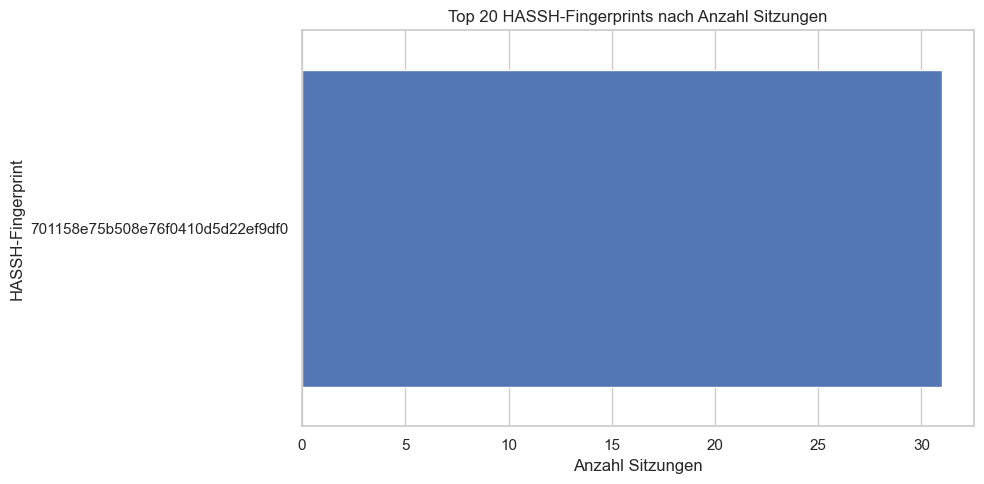

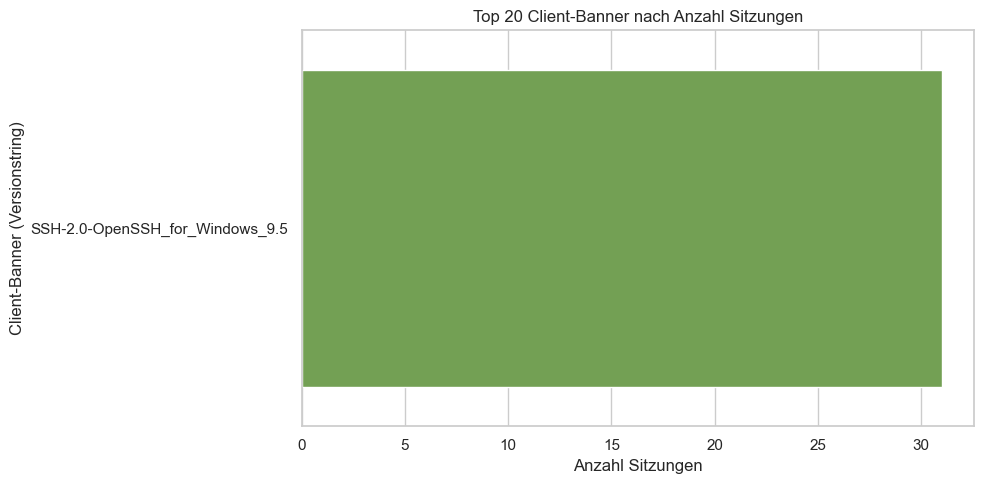

In [10]:
# 3. Top-HASSH und Top-Banner visualisieren

TOP_N = 20

# Top-HASSH-Fingerprints nach Anzahl Sitzungen
if not df.empty and "hassh" in df.columns:
    # Nur nicht-leere Fingerprints berücksichtigen
    top_hassh = (
        df["hassh"]
        .dropna()
        .value_counts()
        .head(TOP_N)
    )
    if not top_hassh.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(
            x=top_hassh.values,
            y=top_hassh.index.astype(str),  # sicherstellen, dass alles als String angezeigt wird
            orient="h",
            color="#4472c4"
        )
        plt.xlabel("Anzahl Sitzungen")
        plt.ylabel("HASSH-Fingerprint")
        plt.title(f"Top {TOP_N} HASSH-Fingerprints nach Anzahl Sitzungen")
        plt.tight_layout()
        plt.show()
    else:
        print("Hinweis: Es liegen keine nicht-leeren HASSH-Fingerprints vor.")

else:
    print("Hinweis: Spalte 'hassh' nicht vorhanden oder DataFrame leer.")

# Top-Client-Banner nach Anzahl Sitzungen
if not df.empty and "client_banner" in df.columns:
    top_banner = (
        df["client_banner"]
        .dropna()
        .value_counts()
        .head(TOP_N)
    )
    if not top_banner.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(
            x=top_banner.values,
            y=top_banner.index.astype(str),
            orient="h",
            color="#70ad47"
        )
        plt.xlabel("Anzahl Sitzungen")
        plt.ylabel("Client-Banner (Versionstring)")
        plt.title(f"Top {TOP_N} Client-Banner nach Anzahl Sitzungen")
        plt.tight_layout()
        plt.show()
    else:
        print("Hinweis: Es liegen keine nicht-leeren Client-Banner vor.")
else:
    print("Hinweis: Spalte 'client_banner' nicht vorhanden oder DataFrame leer.")

Diese Darstellungen können im Ergebniskapitel genutzt werden, um besonders dominante Fingerprints bzw. Bannermuster zu illustrieren und mit Befunden aus der Literatur zu vergleichen (z. B. wenige dominante Tool‑Fingerprints vs. viele seltene Banner [6]).

## 4.3 Analyse von Fingerprints: Häufigkeit, IP-Diversität, Persistenz

Im nächsten Schritt werden Fingerprints auf einer aggregierten Ebene betrachtet. Dazu wird pro HASSH‑Wert (ggf. in Kombination mit einem Banner) ein Aggregat berechnet mit:

- Anzahl Sessions
- Anzahl eindeutiger Quell‑IPs
- erster und letzter Beobachtungszeitpunkt (Persistenz)

Diese Werte können später in Tabellenform (z. B. Top‑Fingerprints) und als Grundlage für Clusterbildung verwendet werden.

In [11]:
# 4. Aggregation auf Fingerprint-Ebene

if df.empty:
    print("Keine Daten vorhanden.")
else:
    # Zeitstempel parsen, falls vorhanden
    if "first_seen" in df.columns:
        df["first_seen_ts"] = df["first_seen"].apply(parse_iso)
    else:
        df["first_seen_ts"] = pd.NaT

    if "last_seen" in df.columns:
        df["last_seen_ts"] = df["last_seen"].apply(parse_iso)
    else:
        df["last_seen_ts"] = pd.NaT

    # Fingerprint-Aggregation nur, wenn HASSH verfügbar ist
    if "hassh" in df.columns:
        # Nur Sitzungen mit gesetztem HASSH betrachten
        df_fp = df.dropna(subset=["hassh"]).copy()
        if df_fp.empty:
            print("Hinweis: Es liegen keine Sitzungen mit HASSH-Fingerprint vor.")
        else:
            grp = df_fp.groupby("hassh", dropna=False)

            # Aggregation auf HASSH-Ebene
            agg = grp.agg(
                sessions=("hassh", "size"),
                unique_src_ips=(
                    "src_ip",
                    lambda x: x.nunique(dropna=True) if "src_ip" in df_fp.columns else np.nan
                ),
                first_seen_min=("first_seen_ts", "min"),
                last_seen_max=("last_seen_ts", "max"),
                example_banner=("client_banner", "first"),
            ).reset_index()

            # Persistenzdauer in Tagen berechnen (falls Zeitfelder vorhanden)
            if "first_seen_min" in agg.columns and "last_seen_max" in agg.columns:
                agg["persistence_days"] = (
                    agg["last_seen_max"] - agg["first_seen_min"]
                ).dt.total_seconds() / 86400.0

            # Nach Häufigkeit sortieren
            agg_sorted = agg.sort_values("sessions", ascending=False)

            # Top-20 Fingerprints anzeigen
            display(agg_sorted.head(20))
    else:
        print("Spalte 'hassh' nicht verfügbar; Fingerprint-Aggregation nicht möglich.")

,hassh,sessions,unique_src_ips,first_seen_min,last_seen_max,example_banner,persistence_days
0,701158e75b508e76f0410d5d22ef9df0,31,2,2025-10-30 19:39:53.647400+00:00,2025-11-07 00:07:16.271905+00:00,SSH-2.0-OpenSSH_for_Windows_9.5,7.185679


Die resultierende Tabelle (`agg_sorted`) eignet sich z. B. als **Tabelle der Top‑Fingerprints** im Ergebniskapitel (mit Spalten: HASSH, Sessions, eindeutige IPs, Beispiel‑Banner, Persistenzdauer [6][3]).

## 4.4 Vergleich HASSH vs. Banner (Diskriminationskraft)

Zur Bewertung der Diskriminationskraft von HASSH im Vergleich zu Versionstrings kann u. a. das Verhältnis „Anzahl unterschiedlicher HASSH‑Werte“ zu „Anzahl unterschiedlicher Bannervarianten“ betrachtet werden. Darüber hinaus ist interessant, wie viele verschiedene Banner zu einem HASSH gehören – dies gibt Hinweise auf Bannermanipulation bei stabilen Algo‑Profilen [3][12].

Anzahl verschiedener HASSH-Fingerprints: 1
Anzahl verschiedener Client-Banner:       1


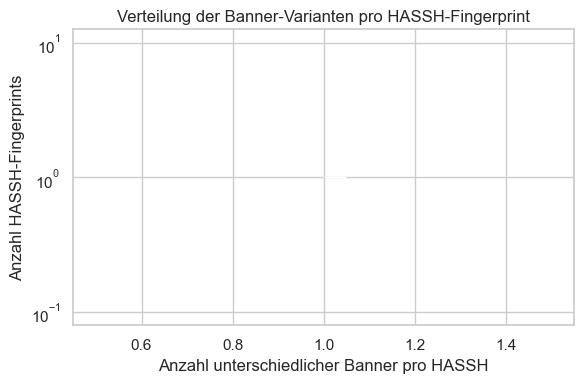


Zusammenfassung 'Banner pro HASSH':
  Minimum: 1
  Median : 1.0
  Maximum: 1


In [12]:
# 5. Vergleich HASSH vs. Banner (Diskriminationskraft und Spoofing-Indikatoren)

if df.empty:
    print("Keine Daten für den Vergleich HASSH vs. Banner vorhanden.")
elif "hassh" not in df.columns or "client_banner" not in df.columns:
    print("Für den Vergleich HASSH vs. Banner fehlen Spalten 'hassh' oder 'client_banner'.")
else:
    # Nur Zeilen mit sowohl HASSH als auch Client-Banner berücksichtigen
    df_hb = df.dropna(subset=["hassh", "client_banner"]).copy()
    if df_hb.empty:
        print("Hinweis: Es liegen keine Sitzungen vor, in denen sowohl HASSH als auch Client-Banner gesetzt sind.")
    else:
        # 1) Globaler Vergleich: wie viele verschiedene HASSH vs. wie viele verschiedene Banner?
        n_hassh = df_hb["hassh"].nunique(dropna=True)
        n_banner = df_hb["client_banner"].nunique(dropna=True)
        print(f"Anzahl verschiedener HASSH-Fingerprints: {n_hassh}")
        print(f"Anzahl verschiedener Client-Banner:       {n_banner}")

        # 2) Wie viele unterschiedliche Banner pro HASSH?
        banner_per_hassh = (
            df_hb
            .groupby("hassh")["client_banner"]
            .nunique(dropna=True)
            .reset_index(name="distinct_banners")
        )

        if banner_per_hassh.empty:
            print("Hinweis: Konnte keine Verteilung der Banner pro HASSH berechnen (leerer Aggregat-DataFrame).")
        else:
            plt.figure(figsize=(6, 4))
            sns.histplot(
                banner_per_hassh["distinct_banners"],
                bins=20,
                log_scale=(False, True)  # y-Achse logarithmisch für viele seltene Werte
            )
            plt.xlabel("Anzahl unterschiedlicher Banner pro HASSH")
            plt.ylabel("Anzahl HASSH-Fingerprints")
            plt.title("Verteilung der Banner-Varianten pro HASSH-Fingerprint")
            plt.tight_layout()
            plt.show()

            # Optional: kurze numerische Zusammenfassung für den Textteil
            print("\nZusammenfassung 'Banner pro HASSH':")
            print("  Minimum:", banner_per_hassh["distinct_banners"].min())
            print("  Median :", banner_per_hassh["distinct_banners"].median())
            print("  Maximum:", banner_per_hassh["distinct_banners"].max())

Diese Analyse unterstützt Aussagen zur **Bannermanipulation bei stabilen Algo‑Profilen** und kann direkt im Ergebnisteil herangezogen werden, um H1 (HASSH vs. Banner) zu diskutieren [3][12].

## 4.5 Zeitliche Muster und Persistenz von Fingerprints

Um H2 (Stabilität von Algo‑Profilen) zu adressieren, werden zeitliche Verläufe einzelner Fingerprints betrachtet. Dazu können z. B. für ausgewählte HASSH‑Werte die Anzahl Sitzungen je Tag geplottet werden [3][16].

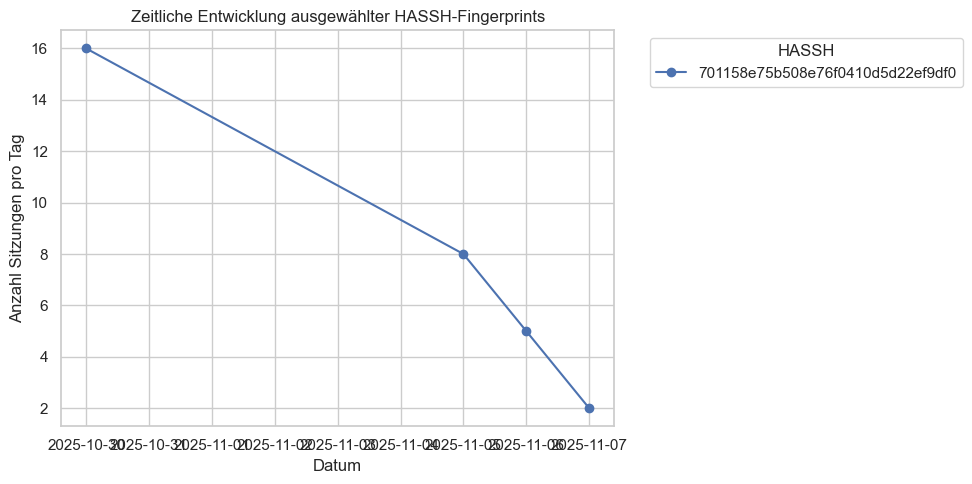

In [14]:
# 6. Zeitliche Entwicklung ausgewählter Fingerprints

if df.empty:
    print("Keine Daten für die zeitliche Analyse vorhanden.")
elif "hassh" not in df.columns or "first_seen" not in df.columns:
    print("Zeitliche Analyse nicht möglich (fehlende Spalten 'hassh' oder 'first_seen').")
else:
    # first_seen in einen timezone-aware Timestamp konvertieren (idempotent, falls schon datetime)
    df["first_seen_ts"] = pd.to_datetime(df["first_seen"], utc=True, errors="coerce")

    if df["first_seen_ts"].isna().all():
        print("Zeitliche Analyse nicht möglich: alle 'first_seen'-Werte sind ungültig oder leer.")
    else:
        # Datumsspalte ableiten
        df["date"] = df["first_seen_ts"].dt.date

        # meistbeobachtete HASSH-Fingerprints (bis zu 3 Stück)
        top_hassh_ids = df["hassh"].dropna().value_counts().head(3).index.tolist()
        if not top_hassh_ids:
            print("Keine HASSH-Fingerprints für die zeitliche Analyse verfügbar.")
        else:
            df_top = df[df["hassh"].isin(top_hassh_ids)].copy()
            ts = df_top.groupby(["date", "hassh"]).size().reset_index(name="sessions")

            plt.figure(figsize=(10, 5))
            for h in top_hassh_ids:
                sub = ts[ts["hassh"] == h]
                plt.plot(sub["date"], sub["sessions"], marker="o", label=h)

            plt.xlabel("Datum")
            plt.ylabel("Anzahl Sitzungen pro Tag")
            plt.title("Zeitliche Entwicklung ausgewählter HASSH-Fingerprints")
            plt.legend(title="HASSH", bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

Diese grafische Darstellung kann verwendet werden, um zu zeigen, ob Fingerprints punktuell, in Wellen (Kampagnen) oder über längere Zeiträume kontinuierlich auftreten [3][16].

## 4.6 Ausblick: Clustering und TI-Export

Abschließend können auf Basis des aggregierten Fingerprint‑DataFrames (`agg_sorted`) weiterführende Analysen erfolgen, etwa:

- Clustering von Fingerprints nach Häufigkeit, IP‑Diversität, Persistenz und einfachen Zeitmerkmalen (z. B. mittels DBSCAN oder hierarchischem Clustering) [26][27]
- Identifikation von Kandidaten für TI‑Indikatoren (hochfrequente, breit verteilte, persistente Fingerprints)
- Export ausgewählter Fingerprints und ihrer Metadaten in ein STIX‑ähnliches JSON‑Format zur späteren Integration in eine STIP‑Plattform [2][21].

Diese Schritte können in separaten Blöcken ergänzt werden, sobald erste Explorationsläufe vorliegen und Hypothesen (z. B. zu Tool‑/Kampagnenclustern) konkretisiert wurden.